# EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss (Classes 2, 3, 5 only)

This notebook trains an EfficientNet-B0 model combining:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (2 < 3 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance
- **Class filtering**: Only trains on ISUP grades 2, 3, and 5 (ignoring 0, 1, 4)

The combination addresses multiple challenges:
1. Ordinal structure ensures predictions respect grade ordering
2. Focal loss down-weights easy examples and focuses on hard misclassifications
3. Entropy filtering removes noisy/ambiguous samples
4. Focused training on clinically relevant subset of grades

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 3  # For ordinal encoding: 3 classes (2,3,5) → 2 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-classes-2-5.pth'
log_path = 'logs/b0-entropy-ordinal-focal-classes-2-5.txt'

Using device: cuda


## Combined Ordinal + Focal Loss

This loss function combines:
1. **Ordinal encoding**: Converts remapped ISUP grades to binary thresholds [1,1,...,1,0,0,...,0]
2. **Focal loss modulation**: Applies (1-p_t)^gamma weighting to focus on hard examples

For the 3 selected classes (2, 3, 5), we remap to (0, 1, 2) and create ordinal encodings:
- ISUP 2 → Class 0: [0, 0]
- ISUP 3 → Class 1: [1, 0]
- ISUP 5 → Class 2: [1, 1]

Formula: `FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, ordinal_targets)`

In [3]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    
    For the 3 classes (remapped 0, 1, 2 from ISUP 2, 3, 5):
    - Class 0: [0, 0]
    - Class 1: [1, 0]
    - Class 2: [1, 1]
    
    Then apply focal loss weighting:
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Calculate binary cross entropy (without reduction)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Calculate p_t: probability of correct class
        # For target=1, p_t=p; for target=0, p_t=1-p
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate focal weight: (1 - p_t)^gamma
        # This down-weights easy examples (high p_t) and focuses on hard examples (low p_t)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=2):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of remapped grades (0, 1, 2)
        num_classes: Number of thresholds (2 for 3 classes)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted class (0, 1, 2)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(alpha=focal_alpha, gamma=focal_gamma)
print(f"Ordinal + Focal Loss initialized")
print(f"  Alpha: {focal_alpha}")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized
  Alpha: 0.25
  Gamma: 2.0


## Load Data with Entropy Filtering and Class Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Filter to only keep classes 2, 3, and 5
df_train_ = df_train_[df_train_['isup_grade'].isin([2, 3, 4, 5])].reset_index(drop=True)
print(f"After class filtering (2-5 only): {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"After entropy filtering: {len(df_train_)}")

# Remap classes: ISUP 2→0, ISUP 3→1, ISUP 5→2
class_mapping = {2: 0, 3: 1, 4: 2, 5: 3}
df_train_['isup_grade_original'] = df_train_['isup_grade']
df_train_['isup_grade'] = df_train_['isup_grade'].map(class_mapping)
print(f"\nClasses remapped: ISUP 2→0, ISUP 3→1, ISUP 4→2, ISUP 5→3")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data and filter
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")
df_test = df_test[df_test['isup_grade'].isin([2, 3, 4, 5])].reset_index(drop=True)
df_test['isup_grade_original'] = df_test['isup_grade']
df_test['isup_grade'] = df_test['isup_grade'].map(class_mapping)

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution (remapped):")
print(df_train['isup_grade'].value_counts().sort_index())

print(f"\nTrain class distribution (original ISUP):")
print(df_train['isup_grade_original'].value_counts().sort_index())

Original records: 9024
After class filtering (2-5 only): 4300
High-entropy samples to remove: 903
After entropy filtering: 4153

Classes remapped: ISUP 2→0, ISUP 3→1, ISUP 4→2, ISUP 5→3

Train: 3318 samples
Validation: 833 samples
Test: 756 samples

Train class distribution (remapped):
isup_grade
0    899
1    826
2    832
3    761
Name: count, dtype: int64

Train class distribution (original ISUP):
isup_grade_original
2    899
3    826
4    832
5    761
Name: count, dtype: int64


## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png", num_classes=3)
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png", num_classes=3)
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png", num_classes=3)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 1106
Validation batches: 278
Test batches: 252


## Model Setup

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds for 3 classes)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 3 (ordinal thresholds for 3 classes)
Dropout rate: 0.6


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with Ordinal + Focal Loss (Classes 2, 3, 5 only)...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training with Ordinal + Focal Loss (Classes 2, 3, 5 only)...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 278/278 [00:47<00:00,  5.91it/s]



Results:
  Train Loss: 0.03410
  Val Loss: 0.03062
  Val Accuracy: 51.62%
  Val Kappa: 0.5985
  Val F1: 0.5134
  Learning Rate: 0.0003000

  Best model saved! Kappa: 0.5985

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 278/278 [00:44<00:00,  6.32it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.03216
  Val Loss: 0.02732
  Val Accuracy: 52.70%
  Val Kappa: 0.6779
  Val F1: 0.5337
  Learning Rate: 0.0003003

  Best model saved! Kappa: 0.6779

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.01668
  Val Loss: 0.02831
  Val Accuracy: 59.42%
  Val Kappa: 0.7086
  Val F1: 0.5963
  Learning Rate: 0.0002020

  No improvement for 5 epoch(s)

Epoch 22/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 278/278 [00:42<00:00,  6.54it/s]



Results:
  Train Loss: 0.01594
  Val Loss: 0.02591
  Val Accuracy: 59.54%
  Val Kappa: 0.7239
  Val F1: 0.5898
  Learning Rate: 0.0001929

  No improvement for 6 epoch(s)

Epoch 23/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 278/278 [00:42<00:00,  6.56it/s]


Results:
  Train Loss: 0.01487
  Val Loss: 0.02818
  Val Accuracy: 59.06%
  Val Kappa: 0.7206
  Val F1: 0.5963
  Learning Rate: 0.0001836

  No improvement for 7 epoch(s)

Early stopping at epoch 23
Best epoch: 16 with Kappa: 0.7311

Training completed!
Best validation Kappa: 0.7311 at epoch 16


## Plot Training History

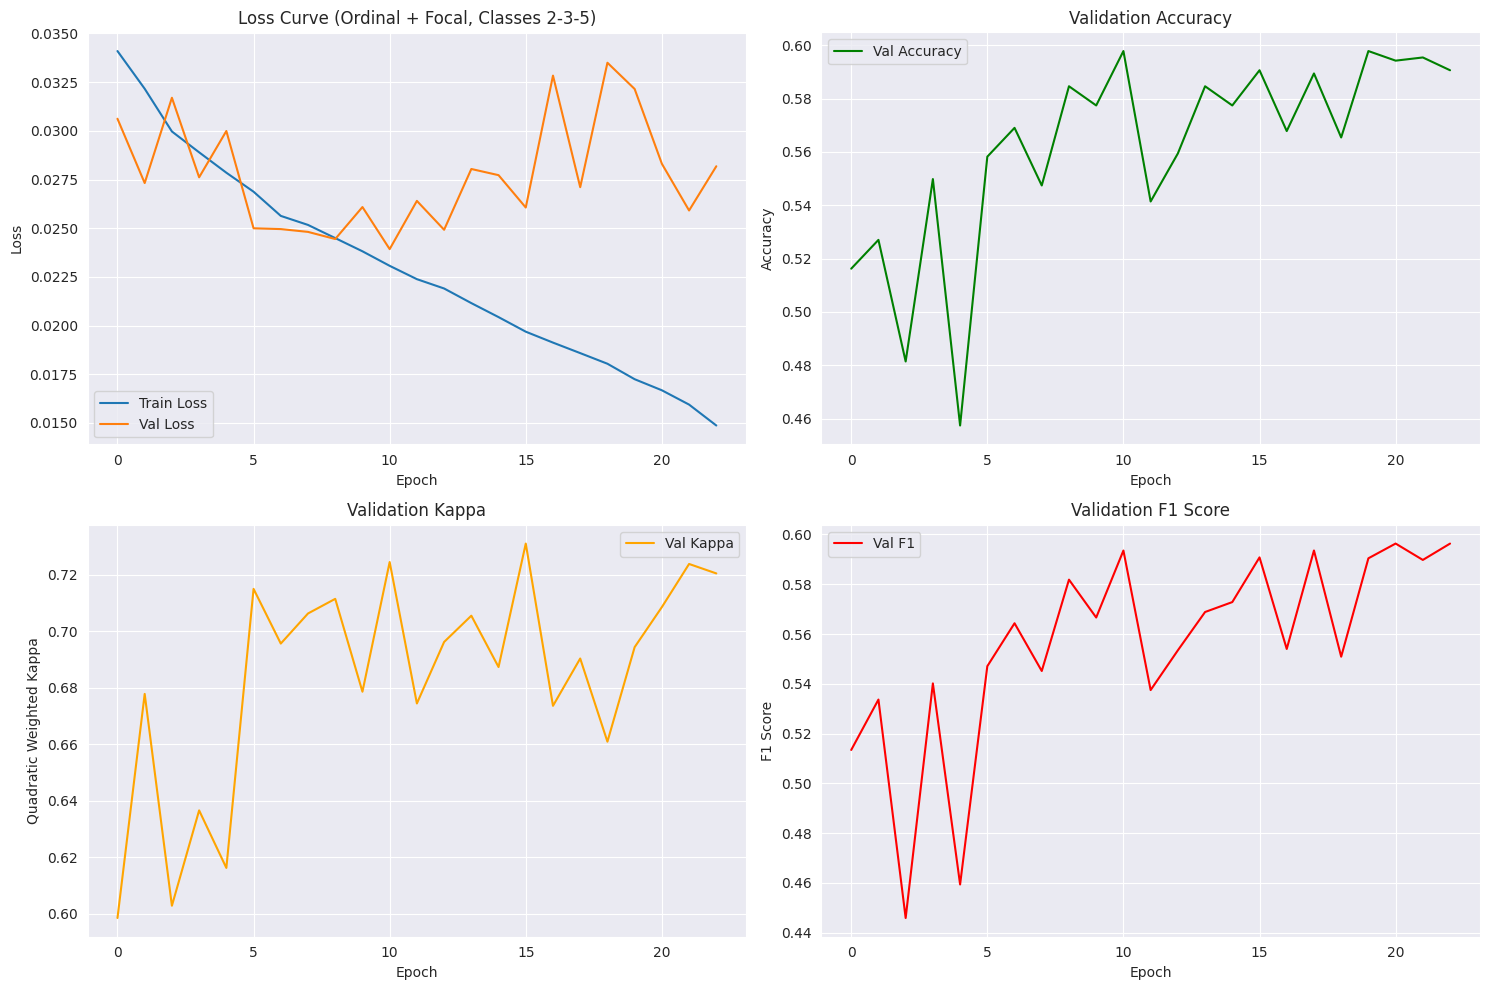

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Ordinal + Focal, Classes 2-3-5)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-classes-2-3-5-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss, Classes 2-3-5)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=['ISUP 2', 'ISUP 3', 'ISUP 5'], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['ISUP 2', 'ISUP 3', 'ISUP 5'],
    yticklabels=['ISUP 2', 'ISUP 3', 'ISUP 5'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal, Classes 2-3-5)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-classes-2-3-5-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('logs/b0-entropy-ordinal-focal-classes-2-3-5-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss (Classes 2, 3, 5)\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=['ISUP 2', 'ISUP 3', 'ISUP 5'], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-classes-2-3-5-test-results.txt")

Evaluating on test set...



Testing: 100%|██████████| 252/252 [00:39<00:00,  6.43it/s]



TEST SET RESULTS (Ordinal + Focal Loss, Classes 2-3-5)
Accuracy: 59.26%
Quadratic Weighted Kappa: 0.7053
Macro F1 Score: 0.5942

Classification Report:


ValueError: Number of classes, 4, does not match size of target_names, 3. Try specifying the labels parameter

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels for classes
classes = ['ISUP 2', 'ISUP 3', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Normalized Confusion Matrix (Ordinal + Focal, Classes 2-3-5)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-classes-2-3-5-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

This notebook trained EfficientNet-B0 with a powerful combination of techniques, focusing on a specific subset of ISUP grades:

1. **Class filtering** - Only trained on ISUP grades 2, 3, and 5 (remapped to 0, 1, 2)
2. **Entropy filtering** - Removed top 20% most difficult/ambiguous samples for cleaner training
3. **Ordinal loss** - Enforced the natural ordering of the selected grades (2 < 3 < 5)
4. **Focal loss** - Down-weighted easy examples and focused learning on hard misclassifications

### How the combined loss works:

- **Class remapping**: ISUP grades filtered and remapped:
  - ISUP 2 → Class 0
  - ISUP 3 → Class 1
  - ISUP 5 → Class 2

- **Ordinal encoding**: Each remapped class k is converted to k binary thresholds
  - Class 0 (ISUP 2): [0,0]
  - Class 1 (ISUP 3): [1,0] (grade > threshold 1)
  - Class 2 (ISUP 5): [1,1] (grade > threshold 1 and > threshold 2)

- **Focal modulation**: Applied to each binary threshold prediction
  - Easy predictions (high confidence): Down-weighted by factor (1-p)^gamma
  - Hard predictions (low confidence): Retain full weight
  - Result: Model focuses on learning difficult threshold boundaries

### Expected benefits:

- Simplified problem: 3 classes instead of 6
- Better handling of class imbalance through focal loss
- Reduced impact of easy negative examples
- Maintained ordinal consistency in predictions
- Focused training on clinically relevant distinction between moderate (2), significant (3), and most severe (5) grades